# **Modelos LSTM — Frontera 01 La Aurora**

En este notebook se trabaja la serie mensual de viajeros que ingresan por la frontera **01 La Aurora**. La idea es probar modelos LSTM con distintas configuraciones, tunear algunos hiperparámetros y después quedarnos con la opción que tenga mejor desempeño.

Se escogió esta serie porque La Aurora es uno de los puntos de ingreso más importantes del país y en el análisis anterior mostró una estacionalidad bastante marcada. Por eso tiene sentido probar si una LSTM logra capturar ese patrón anual sin indicarle explícitamente la estacionalidad, como sí se hace en modelos como SARIMA.


## **1.1. Conjuntos de entrenamiento y prueba**

Para comparar los resultados con los modelos del Laboratorio 1, se usan los mismos archivos de entrenamiento y prueba: entrenamiento.csv y prueba.csv. No se vuelve a partir la data, porque eso haría que la comparación ya no fuera directa.

El entrenamiento va de enero de 2009 a marzo de 2021, con 147 meses. La prueba va de abril de 2021 a junio de 2026, con 63 meses. La partición se mantiene en orden cronológico, porque en series de tiempo no conviene mezclar observaciones pasadas y futuras.

En este caso, la serie de 01 La Aurora se reconstruye filtrando la columna Frontera por ese valor y aplicando la misma transformación logarítmica usada en el laboratorio anterior. Luego, para calcular MAE y RMSE, se regresa a la escala original de viajeros usando la exponencial. Esto permite comparar los errores contra los modelos anteriores en las mismas unidades.

In [1]:
import os
import sys
import warnings
from pathlib import Path

Path("/private/tmp/matplotlib-cache").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "lstm" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import config
import utils

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 5)

SERIE = "fro_aurora"
PERIODO = config.PERIODO

serie_train = utils.construir_serie(SERIE, "train")
serie_prueba = utils.construir_serie(SERIE, "prueba")

serie_train_log = np.log(serie_train)
serie_prueba_log = np.log(serie_prueba)

print("Serie:", config.SERIES_LAB1[SERIE]["etiqueta"])
print(f"Entrenamiento: {serie_train.index.min():%Y-%m} a {serie_train.index.max():%Y-%m}  "
      f"({len(serie_train)} meses)")
print(f"Prueba       : {serie_prueba.index.min():%Y-%m} a {serie_prueba.index.max():%Y-%m}  "
      f"({len(serie_prueba)} meses)")
print("Frecuencia   :", serie_train.index.freqstr, "(mensual, inicio de mes)")
print("Meses sin registro:", int(serie_train.isna().sum() + serie_prueba.isna().sum()))
print()
print("Mejor modelo del Laboratorio 1 para esta serie:")
print(f"  {config.MEJORES_LAB1[SERIE]['modelo']}  "
      f"MAE={config.MEJORES_LAB1[SERIE]['MAE']:,.0f}  "
      f"RMSE={config.MEJORES_LAB1[SERIE]['RMSE']:,.0f}")

serie_train.tail()

Serie: 01 La Aurora
Entrenamiento: 2009-01 a 2021-03  (147 meses)
Prueba       : 2021-04 a 2026-06  (63 meses)
Frecuencia   : MS (mensual, inicio de mes)
Meses sin registro: 0

Mejor modelo del Laboratorio 1 para esta serie:
  Suav. exp. simple  MAE=36,822  RMSE=42,053


Fecha
2020-11-01    38988.000000
2020-12-01    50370.000000
2021-01-01    40801.000000
2021-02-01    28780.000000
2021-03-01    58806.139619
Freq: MS, Name: Viajero, dtype: float64

## **1.2. Diseño del tuneo de hiperparámetros**

Para cumplir con el inciso, se comparan dos tipos de modelos LSTM:

1. **LSTM simple**: tiene una sola capa LSTM. Se usa como punto de comparación porque es un modelo más sencillo y debería tener menor riesgo de sobreajuste.
2. **LSTM apilada**: tiene dos capas LSTM y usa dropout. Esta versión tiene más capacidad para aprender patrones más complejos, pero también puede sobreajustarse más fácil, por eso se regulariza.

Los hiperparámetros que se tunean son:

- ventana: se prueban 12 y 24 meses. Con 12 meses el modelo ve un ciclo anual completo; con 24 meses puede usar dos ciclos anuales.
- unidades: se prueban 16 y 32 unidades. No se usan redes muy grandes porque la serie mensual no tiene demasiadas observaciones.
- dropout: se prueba solo en la LSTM apilada, ya que ahí hay más riesgo de sobreajuste.
- tasa_aprendizaje: se prueban 0.001 y 0.005 para ver qué tan rápido conviene que aprenda Adam.

Se dejan fijos batch_size = 16, epochs = 250 y early stopping. El early stopping ayuda a que el entrenamiento se detenga cuando el modelo ya no mejora, en lugar de forzar todas las épocas.

Para escoger la mejor configuración se usa validación de origen rodante. Esto significa que el modelo siempre entrena con meses anteriores y valida con los meses siguientes, respetando el orden de la serie. El conjunto de prueba no se usa en esta etapa.

In [2]:
grilla_dos_modelos = []

for ventana in (12, 24):
    for tasa_aprendizaje in (0.001, 0.005):
        for unidades in (16, 32):
            grilla_dos_modelos.append({
                "familia": "A_simple",
                "ventana": ventana,
                "unidades": unidades,
                "capas": 1,
                "dropout": 0.0,
                "tasa_aprendizaje": tasa_aprendizaje,
                "epocas": 250,
                "paciencia": 30,
                "lote": 16,
            })

        for dropout in (0.1, 0.2):
            grilla_dos_modelos.append({
                "familia": "B_apilada_dropout",
                "ventana": ventana,
                "unidades": 32,
                "capas": 2,
                "dropout": dropout,
                "tasa_aprendizaje": tasa_aprendizaje,
                "epocas": 250,
                "paciencia": 30,
                "lote": 16,
            })

tabla_grilla = pd.DataFrame(grilla_dos_modelos)
print(f"Configuraciones a evaluar: {len(tabla_grilla)}")
tabla_grilla

Configuraciones a evaluar: 16


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas,paciencia,lote
0,A_simple,12,16,1,0.0,0.001,250,30,16
1,A_simple,12,32,1,0.0,0.001,250,30,16
2,B_apilada_dropout,12,32,2,0.1,0.001,250,30,16
3,B_apilada_dropout,12,32,2,0.2,0.001,250,30,16
4,A_simple,12,16,1,0.0,0.005,250,30,16
5,A_simple,12,32,1,0.0,0.005,250,30,16
6,B_apilada_dropout,12,32,2,0.1,0.005,250,30,16
7,B_apilada_dropout,12,32,2,0.2,0.005,250,30,16
8,A_simple,24,16,1,0.0,0.001,250,30,16
9,A_simple,24,32,1,0.0,0.001,250,30,16


### **1.2.a. Tuneo con validación temporal**

La siguiente celda ejecuta el tuneo. Cada configuración se evalúa en varios cortes de 12 meses y se ordena usando el RMSE promedio de validación en la escala original de viajeros.

In [3]:
USAR_CACHE = True

tabla_tuneo = utils.tunear_con_cache(
    clave_serie=f"{SERIE}_dos_modelos",
    valores_train_log=serie_train_log.values,
    grilla=grilla_dos_modelos,
    usar_cache=USAR_CACHE,
    n_cortes=4,
    tamano_val=12,
    semilla=config.SEMILLA,
    verbose=True,
)

columnas_tuneo = [
    "familia", "ventana", "unidades", "capas", "dropout", "tasa_aprendizaje",
    "RMSE_val", "MAE_val", "RMSE_std", "RMSE_val_sin_ultimo", "n_cortes", "rmse_por_corte",
]

tabla_tuneo[columnas_tuneo].head(10)

Configuraciones     : 16


Cortes de validacion: [(99, 111), (111, 123), (123, 135), (135, 147)]


Entrenamientos      : 64


Semilla             : 123


[cargado] tuneo_lstm_fro_aurora_dos_modelos.csv: 16 ya corridas, se retoman


[ok] el tuneo ya estaba completo


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,RMSE_val,MAE_val,RMSE_std,RMSE_val_sin_ultimo,n_cortes,rmse_por_corte
0,B_apilada_dropout,24,32,2,0.1,0.005,34162.955692,26291.174815,30881.120333,16411.791542,4,"[16562.2, 12256.5, 20416.7, 87416.4]"
1,B_apilada_dropout,12,32,2,0.2,0.005,34723.201553,30591.008422,33797.010294,15462.420473,4,"[12923.7, 9398.6, 24065.0, 92505.5]"
2,A_simple,12,16,1,0.0,0.001,37277.081160,32559.063021,35715.046758,16759.271697,4,"[15659.7, 12375.6, 22242.6, 98830.5]"
3,A_simple,24,32,1,0.0,0.005,37295.143362,32098.092659,34971.067419,17135.544029,4,"[15089.0, 16072.4, 20245.2, 97773.9]"
4,B_apilada_dropout,12,32,2,0.1,0.001,37773.071014,33310.872779,34880.452097,17692.775587,4,"[16044.2, 15061.0, 21973.1, 98014.0]"
5,A_simple,12,32,1,0.0,0.001,37799.679365,32481.361458,38702.544439,15528.094084,4,"[14838.9, 11482.2, 20263.2, 104614.4]"
6,B_apilada_dropout,12,32,2,0.1,0.005,37922.269674,33728.298104,36064.169680,17140.234229,4,"[13963.2, 17205.5, 20252.1, 100268.4]"
7,A_simple,24,16,1,0.0,0.001,38275.840207,34288.172429,34148.088656,18667.760361,4,"[14693.4, 16983.9, 24326.0, 97100.1]"
8,B_apilada_dropout,12,32,2,0.2,0.001,38366.735442,33920.111595,36801.763813,17187.304002,4,"[15328.7, 14277.4, 21955.7, 101905.0]"
9,A_simple,12,32,1,0.0,0.005,38425.769932,33068.583408,36956.876034,17280.598799,4,"[12939.1, 13554.3, 25348.4, 101861.3]"


### **1.2.b. Selección del mejor modelo por familia**

Para mostrar claramente los dos modelos pedidos, se toma el mejor resultado de cada familia: el mejor LSTM simple y el mejor LSTM apilado con dropout.

In [4]:
idx_mejores = tabla_tuneo.groupby("familia")["RMSE_val"].idxmin()
mejor_por_familia = tabla_tuneo.loc[idx_mejores].sort_values("RMSE_val").reset_index(drop=True)
mejor_global = mejor_por_familia.iloc[0]

print("Mejor configuracion global segun validacion temporal:")
print(f"  Familia             : {mejor_global['familia']}")
print(f"  Ventana             : {int(mejor_global['ventana'])} meses")
print(f"  Unidades            : {int(mejor_global['unidades'])}")
print(f"  Capas LSTM          : {int(mejor_global['capas'])}")
print(f"  Dropout             : {float(mejor_global['dropout']):.2f}")
print(f"  Tasa de aprendizaje : {float(mejor_global['tasa_aprendizaje']):.4f}")
print(f"  RMSE validacion     : {mejor_global['RMSE_val']:,.0f} viajeros")
print(f"  Desv. RMSE cortes   : {mejor_global['RMSE_std']:,.0f} viajeros")

mejor_por_familia[columnas_tuneo]

Mejor configuracion global segun validacion temporal:
  Familia             : B_apilada_dropout
  Ventana             : 24 meses
  Unidades            : 32
  Capas LSTM          : 2
  Dropout             : 0.10
  Tasa de aprendizaje : 0.0050
  RMSE validacion     : 34,163 viajeros
  Desv. RMSE cortes   : 30,881 viajeros


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,RMSE_val,MAE_val,RMSE_std,RMSE_val_sin_ultimo,n_cortes,rmse_por_corte
0,B_apilada_dropout,24,32,2,0.1,0.005,34162.955692,26291.174815,30881.120333,16411.791542,4,"[16562.2, 12256.5, 20416.7, 87416.4]"
1,A_simple,12,16,1,0.0,0.001,37277.081160,32559.063021,35715.046758,16759.271697,4,"[15659.7, 12375.6, 22242.6, 98830.5]"


### **1.2.c. Entrenamiento final de los modelos seleccionados**

In [5]:
# Entrenamiento final de la mejor configuracion de cada familia sobre todo el
# entrenamiento, y evaluacion contra prueba en los dos modos de pronostico.
# La mecanica vive en utils.entrenar_evaluar_final porque es identica para
# cualquier serie; aqui solo se decide QUE configuraciones se entrenan.
modelos_finales, filas_resumen = {}, []

for _, fila in mejor_por_familia.iterrows():
    cfg = utils.cfg_desde_fila(fila)
    resultado = utils.entrenar_evaluar_final(cfg, serie_train_log, serie_prueba_log)
    modelos_finales[cfg["familia"]] = resultado
    filas_resumen.append(resultado["resumen"])

tabla_modelos_finales = (pd.DataFrame(filas_resumen)
                         .sort_values("RMSE_recursivo").reset_index(drop=True))
tabla_modelos_finales


,familia,ventana,unidades,capas,dropout,tasa_aprendizaje,epocas_entrenadas,MAE_recursivo,RMSE_recursivo,MAPE_recursivo_%,MAE_un_paso,RMSE_un_paso,MAPE_un_paso_%
0,A_simple,12,16,1,0.0,0.001,250,26587.341197,32124.703398,30.568006,15363.306524,19846.200985,17.773599
1,B_apilada_dropout,24,32,2,0.1,0.005,222,107060.017796,148964.947035,133.186710,35497.708281,51120.704820,46.279772


### **1.2.d. Interpretación de la selección**

La selección del modelo se justifica primero con la validación temporal. En esta parte no se usa el conjunto de prueba, entonces sirve para decidir hiperparámetros sin ver el futuro.

Luego se revisa el desempeño en prueba. Para compararlo con el Laboratorio 1 se usan el MAE y el RMSE, porque ese pronóstico se parece más al escenario real de predecir varios meses hacia adelante.

Si gana la LSTM apilada, se puede interpretar que la serie necesitaba un modelo con más capacidad. Si gana la LSTM simple, significa que una arquitectura más sencilla generalizó mejor, lo cual también tiene sentido porque hay pocos datos mensuales y la pandemia hace más difícil el pronóstico.

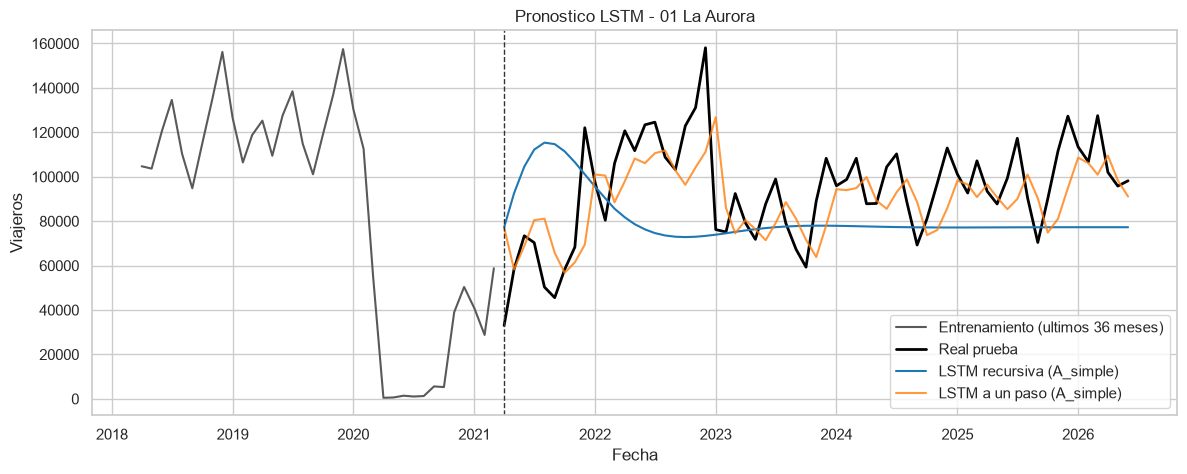

In [6]:
mejor_familia_prueba = tabla_modelos_finales.iloc[0]["familia"]
pred_mejor = modelos_finales[mejor_familia_prueba]["predicciones"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_train.tail(36).index, serie_train.tail(36).values, label="Entrenamiento (ultimos 36 meses)", color="0.35")
ax.plot(serie_prueba.index, serie_prueba.values, label="Real prueba", color="black", linewidth=2)
ax.plot(pred_mejor.index, pred_mejor["pred_recursiva"], label=f"LSTM recursiva ({mejor_familia_prueba})", color="#1f77b4")
ax.plot(pred_mejor.index, pred_mejor["pred_un_paso"], label=f"LSTM a un paso ({mejor_familia_prueba})", color="#ff7f0e", alpha=0.8)

ax.axvline(serie_prueba.index.min(), color="0.2", linestyle="--", linewidth=1)
ax.set_title(f"Pronostico LSTM - {config.SERIES_LAB1[SERIE]['etiqueta']}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Viajeros")
ax.legend()
plt.show()

### **1.2.e. Comparación de los dos modelos contra el conjunto de prueba**


In [7]:
# Comparacion de ambos modelos sobre el conjunto de PRUEBA, en los dos modos.
comparacion_modelos = tabla_modelos_finales[[
    "familia", "ventana", "unidades", "tasa_aprendizaje",
    "RMSE_recursivo", "MAPE_recursivo_%", "RMSE_un_paso", "MAPE_un_paso_%",
]].copy()

display(comparacion_modelos.style.format({
    "tasa_aprendizaje": "{:.4f}",
    "RMSE_recursivo": "{:,.0f}", "MAPE_recursivo_%": "{:.1f}",
    "RMSE_un_paso": "{:,.0f}", "MAPE_un_paso_%": "{:.1f}",
}).hide(axis="index"))


familia,ventana,unidades,tasa_aprendizaje,RMSE_recursivo,MAPE_recursivo_%,RMSE_un_paso,MAPE_un_paso_%
A_simple,12,16,0.0010,"32,125",30.6,"19,846",17.8
B_apilada_dropout,24,32,0.0050,"148,965",133.2,"51,121",46.3


In [8]:
# Mejor modelo por RMSE recursivo y sus diferencias contra el segundo.
mejor = utils.reporte_mejor_vs_segundo(tabla_modelos_finales)


MEJOR MODELO LSTM: familia A_simple
Configuracion  : ventana=12, unidades=16, capas=1, dropout=0.0, lr=0.0010
Epocas         : 250
Recursivo      : RMSE 32,125  MAE 26,587  MAPE 30.6%
A un paso      : RMSE 19,846  MAE 15,363  MAPE 17.8%

Frente al segundo (familia B_apilada_dropout, lr=0.0050):
  RMSE : 32,125 vs 148,965  -> 116,840 menos (78.4% mejor)
  MAPE : 30.6% vs 133.2%  -> 102.6 puntos porcentuales menos

Recursivo contra un paso (veces que crece el error al extrapolar):
  A_simple               1.6x
  B_apilada_dropout      2.9x


## **1.3. Predicción con el mejor modelo**

Con el mejor modelo se predice el conjunto de prueba completo, de abril de 2021 a junio de 2026, y
adicional se extiende el pronóstico hasta diciembre de 2027, siguiendo el mismo criterio que se usó
en el Laboratorio 1 para poder comparar las proyecciones de forma equivalente.

Cabe mencionar que la extensión más allá de junio de 2026 es un pronóstico puro, y por curiosidad
de conocer lo que el mejor modelo espera para el siguiente año.

Adicional, conviene tener presente que el mejor modelo de esta serie resultó ser el más simple de todos los probados, es decir una sola capa LSTM con 16 unidades y sin dropout. Bajo esta idea, la proyección que se ve a continuación no viene de un modelo con mucha capacidad de memoria, sino del que mejor toleró extrapolar sin desestabilizarse.


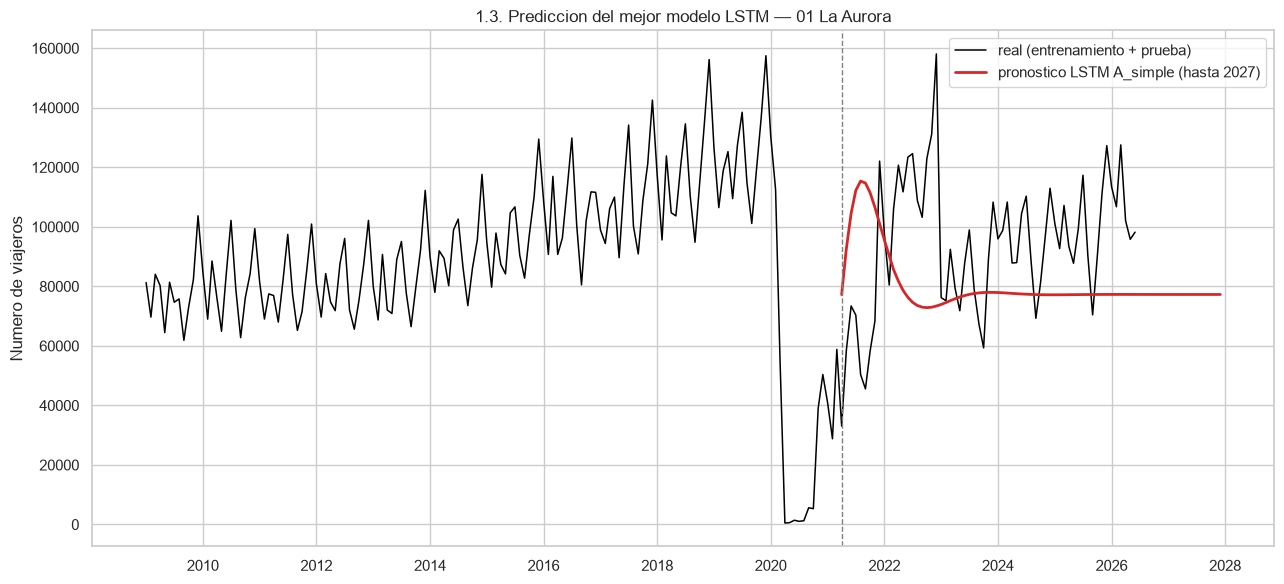

,real,predicho_LSTM
2022,"1,388,401","948,476"
2023,"984,552","919,299"
2024,"1,142,624","929,444"
2025,"1,188,605","926,640"
2026,"643,675","927,268"
2027,nan,"927,143"


In [9]:
# Pronostico del mejor modelo, extendido hasta diciembre de 2027.
familia_mejor = mejor["familia"]
ajuste_mejor = modelos_finales[familia_mejor]
pred_mejor = ajuste_mejor["predicciones"]
pred_futuro = utils.pronostico_extendido(ajuste_mejor, int(mejor["ventana"]))

serie_real_completa = pd.concat([serie_train, serie_prueba])

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_real_completa.index, serie_real_completa.values,
        color="black", linewidth=1.1, label="real (entrenamiento + prueba)")
ax.plot(pred_futuro.index, pred_futuro.values, color="tab:red", linewidth=2,
        label=f"pronostico LSTM {familia_mejor} (hasta 2027)")
ax.axvline(serie_prueba.index[0], color="gray", linestyle="--", linewidth=1)
ax.set_title(f"1.3. Prediccion del mejor modelo LSTM — {config.SERIES_LAB1[SERIE]['etiqueta']}")
ax.set_ylabel("Numero de viajeros")
ax.legend()
plt.tight_layout()
plt.show()

# Total anual real contra predicho, mismo criterio de acumulado del Lab 1.
totales_anuales = pd.DataFrame({
    "real": serie_real_completa.groupby(serie_real_completa.index.year).sum(),
    "predicho_LSTM": pred_futuro.groupby(pred_futuro.index.year).sum(),
}).loc[[2022, 2023, 2024, 2025, 2026, 2027]]
display(totales_anuales.style.format("{:,.0f}"))


## **1.4. Comparación contra el mejor modelo del Laboratorio 1**

Finalmente se compara el mejor modelo LSTM contra el mejor modelo que se obtuvo para esta serie en
el laboratorio anterior. Los criterios que se siguieron para que la comparación sea válida son
tres. Primero, se usaron **los mismos conjuntos de entrenamiento y prueba**, sin volver a decidir
nada sobre los datos. Segundo, se evaluó **la misma tarea**: un pronóstico de 63 meses desde el
final del entrenamiento, sin que el modelo vuelva a ver ningún dato real del período de prueba, que
es exactamente lo que hicieron los modelos del Laboratorio 1 con su `forecast`. Y tercero, los
errores se calcularon **en la escala original de viajeros**, deshaciendo el logaritmo, de tal forma
que ambos modelos se miden en las mismas unidades.

---

### **Discusión**

Primero, entre los dos modelos entrenados se establece que el mejor LSTM fue el de la familia
**A simple**, evaluado en pronóstico recursivo, y esto se determina al validar con las métricas
generadas sobre el conjunto de prueba, lo cual se ve reflejado tanto en el RMSE como en el MAE, los
cuales son considerablemente menores a lo presentado por el otro modelo.

Asimismo, a la hora de compararlo contra el mejor modelo, este era el del Laboratorio 1, el cual era
el suavizamiento exponencial simple. Y como se estableció en ese laboratorio, los modelos que se
basaban en aprender la tendencia fallaban rotundamente, ya que dada la caída repentina que generó la
pandemia, esto hacía que aprendieran eso como un patrón y que se terminara quedando en un punto
donde no lograban registrar que después del 2021 regresaba otra vez a ir creciendo el turismo.

Al comparar ambos, en este caso el LSTM presentó ser un mejor modelo, teniendo un MAE de 26,587
contra 36,822 del suavizamiento. Asimismo, si nos fijamos en el RMSE, castigando errores grandes,
vemos que este se queda en 32,125 mientras que el del suavizamiento es mayor por casi 10,000, con un
valor de 42,053.

No obstante, ambos tienen un MAPE bastante elevado, siendo el del LSTM de 30.6 y el del suavizamiento
de 36.6. Una diferencia de 6 puntos porcentuales, pero ambos estando arriba del 30%. Lo que quiere decir es que nuestro
modelo en promedio se equivoca en un 30% de las predicciones, lo cual es un valor bastante elevado y
no un modelo que se podría utilizar en producción.

Sin embargo, se puede justificar de que por el tipo de modelos que se están utilizando, se podría
tratar, al menos en el caso del LSTM, de probar con tasas de aprendizaje con valores más bajos pero
utilizando dropouts para evitar el sobreajuste. Esto sí se contará con los recursos.

---


In [10]:
# Comparacion contra el mejor modelo del Lab 1. El MAPE de aquel modelo no se
# reporto en el laboratorio anterior, asi que utils lo recalcula reajustandolo y
# valida que reproduzca exacto el MAE y el RMSE que si se reportaron.
comparacion_lab1 = utils.reporte_comparacion_lab1(SERIE, mejor)

display(comparacion_lab1.style.format(
    {"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "MAPE_%": "{:.1f}"}, na_rep="n/d"
).hide(axis="index"))


[ok] el modelo del Lab 1 se reproduce exacto para fro_aurora (MAE 36,822 vs 36,822)
1.4. 01 La Aurora
Laboratorio 2 : LSTM A_simple  MAE=26,587  RMSE=32,125  MAPE=30.6%
Laboratorio 1 : Suav. exp. simple  MAE=36,822  RMSE=42,053  MAPE=36.6%
Diferencia    : -10,235 en MAE (-27.8%)  |  -9,928 en RMSE (-23.6%)
Veredicto     : la LSTM SI supero al mejor modelo del Laboratorio 1 en esta serie.


modelo,MAE,RMSE,MAPE_%,origen
LSTM A_simple,"26,587","32,125",30.6,Laboratorio 2
Suav. exp. simple,"36,822","42,053",36.6,Laboratorio 1


In [11]:
# Exportacion, para que el informe se arme desde archivos y no desde numeros
# copiados a mano de la salida del notebook.
config.DIR_TABLAS.mkdir(parents=True, exist_ok=True)
pred_mejor.to_csv(config.DIR_TABLAS / f"predicciones_lstm_{SERIE}.csv", index_label="Fecha")
tabla_modelos_finales.to_csv(config.DIR_TABLAS / f"metricas_lstm_{SERIE}.csv", index=False)
comparacion_lab1.to_csv(config.DIR_TABLAS / f"comparacion_lstm_lab1_{SERIE}.csv", index=False)
print(f"[guardado] predicciones, metricas y comparacion en {config.DIR_TABLAS}")


[guardado] predicciones, metricas y comparacion en /Users/bryan/Documents/DataScience/Laboratorio2_Series_de_Tiempo/resultados/tablas
